<a href="https://colab.research.google.com/github/MaryamAli-2020/Ajman_Data_Inisights_Generator/blob/main/Data_Mining_Assignment_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Libraries

In [1]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import HistGradientBoostingClassifier
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

## Reading the dataset

In [4]:
# read the dataset
df = pd.read_csv('/content/loan_approval_dataset.csv')
display(df.head())

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
print("1. DATA EXPLORATION")
print("-" * 50)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn info:")
print(df.info())

1. DATA EXPLORATION
--------------------------------------------------
Dataset shape: (4269, 13)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_s

## **Data Pre-processing**

In [6]:
df.columns = df.columns.str.strip() #remove space in colums

for columX in df.select_dtypes(include=['object']).columns: #remove space in rows
    df[columX] = df[columX].str.strip()

In [7]:
# make all columX object=text to lowercase
for columX in df.select_dtypes(include=['object']).columns:
    df[columX] = df[columX].str.lower()

# Loop through object=text and remove special character
for columX in df.select_dtypes(include=['object']).columns:
    df[columX] = df[columX].str.replace('*', '', regex=False)
    df[columX] = df[columX].str.replace('"', '', regex=False)
    df[columX] = df[columX].str.replace("'", '', regex=False)
    df[columX] = df[columX].str.replace('>', '', regex=False)
    df[columX] = df[columX].str.replace('<', '', regex=False)


In [8]:
display(df.head())

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,graduate,no,9600000,29900000,12,778,2400000,17600000,22700000,8000000,approved
1,2,0,not graduate,yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,rejected
2,3,3,graduate,no,9100000,29700000,20,506,7100000,4500000,33300000,12800000,rejected
3,4,3,graduate,no,8200000,30700000,8,467,18200000,3300000,23300000,7900000,rejected
4,5,5,not graduate,yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,rejected


In [9]:
df['self_employed'] = df['self_employed'].replace({'yes': 1, 'no': 0}) #replace yes and no with 1&0s
df['education'] = df['education'].replace({'graduate': 1, 'not graduate': 0}) #same appove
df['loan_status'] = df['loan_status'].replace({'approved': 1, 'rejected': 0}) #same appove

In [10]:
display(df.head())

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [11]:
#check for missing values in each column
missing_values = df.isnull().sum()

display(missing_values)

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [12]:
df = df.drop_duplicates(subset=['loan_id'], keep='first') #remove any duplicates using the ID value

df = df.dropna() #remove rows with any missing data

In [13]:
df = df.drop(columns=['loan_id']) #dropp unnecessary ID column

In [14]:
df.shape #to see if any chnage happened or not

(4269, 12)

### **Feature Engineering**

In [15]:
# Financial ratios - these are powerful features for loan prediction
df['loan_to_income_ratio'] = df['loan_amount'] / df['income_annum']
df['total_assets'] = (df['residential_assets_value'] +
                           df['commercial_assets_value'] +
                           df['luxury_assets_value'] +
                           df['bank_asset_value'])

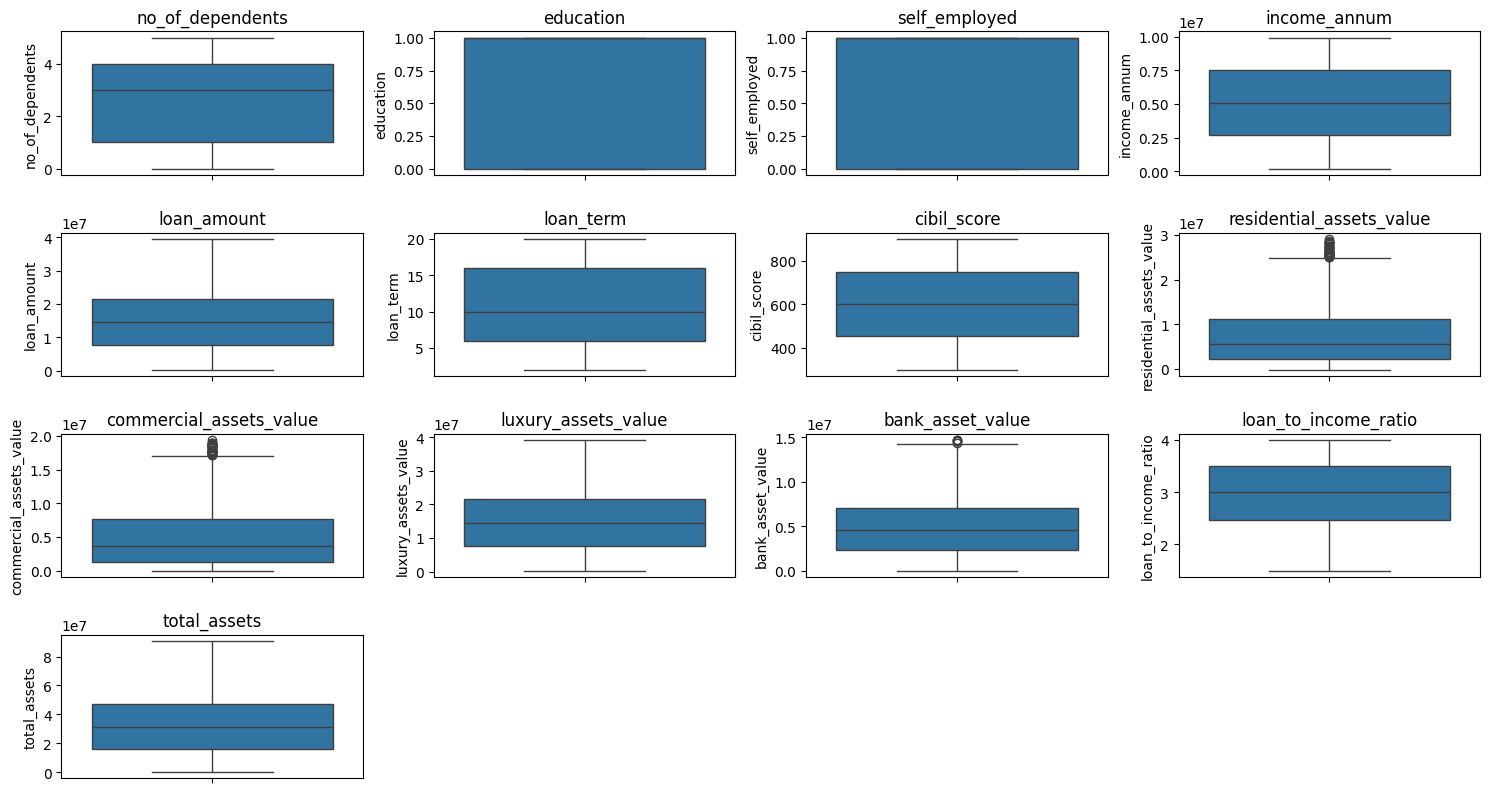

In [16]:
# Select only the numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Exclude the target variable if it's not relevant for outlier analysis
if 'loan_status' in numerical_cols:
    numerical_cols = numerical_cols.drop('loan_status')

# Create box plots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [17]:
# Outlier detection using IQR method
def detect_outliers(df, columns):
    outlier_indices = set()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.update(outliers)
    return list(outlier_indices)

numerical_cols = ['income_annum', 'loan_amount', 'cibil_score', 'loan_to_income_ratio', 'total_assets']
outlier_indices = detect_outliers(df, numerical_cols)
print(f"Outliers detected: {len(outlier_indices)} rows")

Outliers detected: 0 rows


In [18]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,loan_to_income_ratio,total_assets
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,3.114583,50700000
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,2.975610,17000000
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,3.263736,57700000
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,3.743902,52700000
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,2.469388,55000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,2.300000,7400000
4265,0,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,3.424242,20000000
4266,2,0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,3.676923,39000000
4267,1,0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,3.121951,28800000


### **Standardizing the Columns**

In [20]:
# Encode categorical variables
le_education = LabelEncoder()
le_employed = LabelEncoder()
le_target = LabelEncoder()

df['education_encoded'] = le_education.fit_transform(df['education'])
df['self_employed_encoded'] = le_employed.fit_transform(df['self_employed'])
df['loan_status_encoded'] = le_target.fit_transform(df['loan_status'])

print("Categorical encoding completed")

Categorical encoding completed


In [22]:
# Select features for modeling
feature_columns = ['no_of_dependents', 'education_encoded', 'self_employed_encoded',
                  'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
                  'residential_assets_value', 'commercial_assets_value',
                  'luxury_assets_value', 'bank_asset_value',
                  'loan_to_income_ratio', 'total_assets']

X = df[feature_columns]
y = df['loan_status_encoded']

print(f"Features selected: {len(feature_columns)}")
print(f"Feature names: {feature_columns}")

Features selected: 13
Feature names: ['no_of_dependents', 'education_encoded', 'self_employed_encoded', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_to_income_ratio', 'total_assets']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
# Scale features (important for some models)
scaler = RobustScaler()  # More robust to outliers than StandardScaler
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (3415, 13), Test set: (854, 13)


In [26]:
X_train_scaled

array([[ 0.33333333,  0.        , -1.        , ..., -0.41304348,
        -0.02003191, -0.39144737],
       [ 0.        ,  0.        ,  0.        , ..., -0.17391304,
        -0.11604695,  0.11184211],
       [-0.33333333,  0.        ,  0.        , ...,  0.60869565,
        -0.23741528,  1.24013158],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.19565217,
         0.36284222,  0.00986842],
       [-1.        ,  0.        , -1.        , ...,  0.36956522,
         0.19667698, -0.39144737],
       [ 0.        ,  0.        , -1.        , ...,  1.58695652,
        -0.65558992,  0.75986842]])

In [27]:
X_test_scaled

array([[ 0.        , -1.        ,  0.        , ...,  0.34782609,
         0.7530069 , -0.18421053],
       [ 0.33333333, -1.        ,  0.        , ..., -0.30434783,
        -0.34118873, -0.35855263],
       [-0.66666667,  0.        , -1.        , ...,  0.32608696,
         0.94951274,  0.72039474],
       ...,
       [ 0.33333333,  0.        ,  0.        , ...,  0.52173913,
        -0.63420188, -0.15789474],
       [ 0.66666667,  0.        , -1.        , ..., -0.89130435,
         0.64102126, -0.98026316],
       [ 0.        ,  0.        ,  0.        , ...,  0.52173913,
         0.66942093,  1.12828947]])

In [28]:
# count the occurrences of each value in the 'loan_status' column
loan_status_counts = df['loan_status'].value_counts()

display(loan_status_counts)

,count
loan_status,
1,2656
0,1613


In [29]:
class_counts = df['loan_status'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Class imbalance ratio: {imbalance_ratio:.2f}")
if imbalance_ratio > 3:
    print("⚠️  High class imbalance detected - using stratified sampling")

Class imbalance ratio: 1.65


## **Data Processing**

### **Models**

In [30]:
models = {
    'LightGBM': lgb.LGBMClassifier(
        objective='binary',
        boosting_type='gbdt',
        num_leaves=31,
        learning_rate=0.05,
        feature_fraction=0.9,
        bagging_fraction=0.8,
        bagging_freq=5,
        verbose=-1,
        random_state=42
    ),

    'XGBoost': xgb.XGBClassifier(
        objective='binary:logistic',
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ),

    'CatBoost': CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        bootstrap_type='Bernoulli',
        subsample=0.8,
        random_seed=42,
        verbose=False
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=1000,
        max_depth=6,
        min_samples_leaf=20,
        l2_regularization=0.1,
        random_state=42
    )
}

In [31]:
# Train and evaluate models
results = {}
cv_scores = {}

print("Training models...")
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for HistGradientBoosting, original for tree-based models
    if name == 'HistGradientBoosting':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        # Cross-validation
        cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        # Cross-validation
        cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate metrics
    auc_score = roc_auc_score(y_test, y_pred_proba)

    results[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'auc_score': auc_score,
        'cv_mean': cv_score.mean(),
        'cv_std': cv_score.std()
    }

    print(f"{name} - AUC: {auc_score:.4f}, CV Score: {cv_score.mean():.4f} (+/- {cv_score.std()*2:.4f})")

Training models...

Training LightGBM...
LightGBM - AUC: 0.9994, CV Score: 0.9987 (+/- 0.0031)

Training XGBoost...
XGBoost - AUC: 0.9991, CV Score: 0.9984 (+/- 0.0033)

Training CatBoost...
CatBoost - AUC: 0.9998, CV Score: 0.9990 (+/- 0.0014)

Training HistGradientBoosting...
HistGradientBoosting - AUC: 0.9996, CV Score: 0.9990 (+/- 0.0015)


### **Evaluation**

In [32]:
# Detailed evaluation for each model
for name, result in results.items():
    print(f"\n{name} Detailed Results:")
    print("-" * 30)
    print("Classification Report:")
    # Convert the numpy array of integer class labels to a list of strings
    target_names_str = [str(cls) for cls in le_target.classes_]
    print(classification_report(y_test, result['predictions'],
                              target_names=target_names_str))

    # Feature importance (for tree-based models)
    if hasattr(result['model'], 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': feature_columns,
            'importance': result['model'].feature_importances_
        }).sort_values('importance', ascending=False)

        print("\nTop 10 Important Features:")
        print(feature_importance.head(10).to_string(index=False))


LightGBM Detailed Results:
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       323
           1       0.99      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      0.99      1.00       854
weighted avg       1.00      1.00      1.00       854


Top 10 Important Features:
                 feature  importance
    loan_to_income_ratio         601
residential_assets_value         557
 commercial_assets_value         390
             cibil_score         275
            total_assets         235
               loan_term         185
             loan_amount         184
     luxury_assets_value         182
        bank_asset_value         134
            income_annum          92

XGBoost Detailed Results:
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1

In [33]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'AUC Score': [results[name]['auc_score'] for name in results.keys()],
    'CV Mean': [results[name]['cv_mean'] for name in results.keys()],
    'CV Std': [results[name]['cv_std'] for name in results.keys()]
}).sort_values('AUC Score', ascending=False)

print("Model Performance Ranking:")
print(comparison_df.to_string(index=False, float_format='%.4f'))

Model Performance Ranking:
               Model  AUC Score  CV Mean  CV Std
            CatBoost     0.9998   0.9990  0.0007
HistGradientBoosting     0.9996   0.9990  0.0007
            LightGBM     0.9994   0.9987  0.0015
             XGBoost     0.9991   0.9984  0.0016


In [34]:
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 BEST PERFORMING MODEL: {best_model_name}")
print(f"AUC Score: {results[best_model_name]['auc_score']:.4f}")
print(f"Cross-validation: {results[best_model_name]['cv_mean']:.4f} (+/- {results[best_model_name]['cv_std']*2:.4f})")


🏆 BEST PERFORMING MODEL: CatBoost
AUC Score: 0.9998
Cross-validation: 0.9990 (+/- 0.0014)
